In [ ]:
!pip install -q -U accelerate trl
!pip install -q unsloth transformers peft datasets httpx websocket-client matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import json, os, random, re, sys
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List

import torch
from unsloth import FastLanguageModel
from trl import GRPOConfig, GRPOTrainer
from datasets import Dataset


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
MODEL_NAME  = "unsloth/Qwen2.5-1.5B-Instruct"
MAX_SEQ_LEN = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LEN,
    dtype          = None,
    load_in_4bit   = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    target_modules = ["q_proj","k_proj","v_proj","o_proj",
                      "gate_proj","up_proj","down_proj"],
    lora_alpha     = 16,
    lora_dropout   = 0,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
    random_state   = 42,
)
print("Model loaded:", MODEL_NAME)


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded: unsloth/Qwen2.5-1.5B-Instruct


In [ ]:
import httpx, time

ENV_URL = "https://ps2181-invoice-processing-pipeline.hf.space"

for i in range(5):
    try:
        r = httpx.get(f"{ENV_URL}/health", timeout=30)
        if r.status_code == 200:
            print("Space is up:", r.json())
            break
    except Exception as e:
        print(f"Attempt {i+1}/5: {e}")
    print("Waiting 15s...")
    time.sleep(15)
else:
    print("Space offline — training will use local dataset only.")


Space is up: {'status': 'ok', 'environment': 'invoice_processing_pipeline', 'active_sessions': 200}


In [ ]:
def _parse_json_safe(text: str) -> dict:
    text = text.strip()
    if text.startswith("```"):
        text = text.split("\n", 1)[-1] if "\n" in text else text[3:]
        if text.endswith("```"):
            text = text[:-3]
        text = text.strip()
    try:
        result = json.loads(text)
        if isinstance(result, list):
            result = result[0] if result and isinstance(result[0], dict) else {}
        return result if isinstance(result, dict) else {}
    except (json.JSONDecodeError, IndexError):
        return {}


def reward_format(completions, ground_truth=None, **kwargs) -> list:
    required = {"vendor", "date", "currency", "total", "line_items"}
    scores = []
    for c in completions:
        parsed = _parse_json_safe(c[0]["content"] if isinstance(c, list) else c)
        if not isinstance(parsed, dict):
            scores.append(0.0)
            continue
        scores.append(len(required & set(parsed.keys())) / len(required))
    return scores


def reward_field_accuracy(completions, ground_truth=None, **kwargs) -> list:
    ground_truth = ground_truth or [{}] * len(completions)
    scores = []
    for c, gt in zip(completions, ground_truth):
        parsed = _parse_json_safe(c[0]["content"] if isinstance(c, list) else c)
        if not isinstance(parsed, dict) or not gt:
            scores.append(0.0)
            continue
        score = total_w = 0.0
        checks = [
            ("vendor",   0.15, lambda s, g: str(s).strip().lower() == str(g).strip().lower()),
            ("date",     0.10, lambda s, g: str(s).strip() == str(g).strip()),
            ("currency", 0.05, lambda s, g: str(s).strip().upper() == str(g).strip().upper()),
            ("total",    0.20, lambda s, g: abs(float(s) - float(g)) < 0.02),
        ]
        for key, w, fn in checks:
            total_w += w
            if key in parsed and key in gt:
                try:
                    if fn(parsed[key], gt[key]):
                        score += w
                except: pass
        true_descs = {str(it.get("description","")).lower() for it in gt.get("line_items",[])}
        sub_descs  = {str(it.get("description","")).lower() for it in parsed.get("line_items",[])}
        item_w = 0.50
        total_w += item_w
        if true_descs:
            score += item_w * len(true_descs & sub_descs) / len(true_descs)
        scores.append(score / total_w if total_w else 0.0)
    return scores


def reward_math_consistency(completions, ground_truth=None, **kwargs) -> list:
    scores = []
    for c in completions:
        parsed = _parse_json_safe(c[0]["content"] if isinstance(c, list) else c)
        if not isinstance(parsed, dict):
            scores.append(0.0)
            continue
        items = parsed.get("line_items", [])
        if not items:
            scores.append(0.0)
            continue
        ok = total = 0
        line_sum = 0.0
        for it in items:
            try:
                qty, up, amt = float(it["qty"]), float(it["unit_price"]), float(it["amount"])
                line_sum += amt
                total += 1
                if abs(amt - round(qty * up, 2)) < 0.02:
                    ok += 1
            except: total += 1
        try:
            total += 1
            if abs(float(parsed.get("total", -9999)) - round(line_sum, 2)) < 0.02:
                ok += 1
        except: total += 1
        scores.append((ok / max(total, 1)) * 0.5)   # scaled to 0–0.5
    return scores


def reward_completeness(completions, ground_truth=None, **kwargs) -> list:
    ground_truth = ground_truth or [{}] * len(completions)
    scores = []
    for c, gt in zip(completions, ground_truth):
        parsed = _parse_json_safe(c[0]["content"] if isinstance(c, list) else c)
        if not isinstance(parsed, dict):
            scores.append(0.0)
            continue
        true_descs = {str(it.get("description","")).lower() for it in gt.get("line_items",[])}
        if not true_descs:
            scores.append(1.0)
            continue
        sub_descs = {str(it.get("description","")).lower() for it in parsed.get("line_items",[])}
        scores.append(len(true_descs & sub_descs) / len(true_descs))
    return scores

print("Reward functions defined.")

def reward_environment_score(completions, episode_id=None, task_id=None, **kwargs) -> list:
    episode_ids = episode_id or []
    task_ids    = task_id or []
    scores = []
    for i, c in enumerate(completions):
        text   = c[0]["content"] if isinstance(c, list) else c
        parsed = _parse_json_safe(text)
        try:
            ep_id = episode_ids[i] if i < len(episode_ids) else None
            tid   = task_ids[i] if i < len(task_ids) else "easy"

            # Try original episode first
            if ep_id:
                grade_r = httpx.post(
                    f"{ENV_URL}/grader",
                    json={"extracted_data": parsed, "episode_id": ep_id},
                    timeout=15,
                )
                if grade_r.status_code == 200:
                    scores.append(float(grade_r.json().get("score", 0.1)))
                    continue

            # Session expired — reset same task and grade
            reset_r = httpx.post(
                f"{ENV_URL}/reset",
                json={"task_id": tid},
                timeout=15,
            )
            if reset_r.status_code != 200:
                scores.append(0.1)
                continue
            new_ep_id = reset_r.json()["info"]["episode_id"]
            grade_r = httpx.post(
                f"{ENV_URL}/grader",
                json={"extracted_data": parsed, "episode_id": new_ep_id},
                timeout=15,
            )
            scores.append(float(grade_r.json().get("score", 0.1)) if grade_r.status_code == 200 else 0.1)

        except Exception:
            scores.append(0.1)
    return scores





Reward functions defined.


In [ ]:
import httpx, time, random
from collections import Counter

ENV_URL = "https://ps2181-invoice-processing-pipeline.hf.space"

TASK_PROMPTS = {
    "easy":         "Extract invoice fields. Return JSON only: {vendor, date (YYYY-MM-DD), currency (USD/EUR/GBP), total (float), line_items [{description, qty, unit_price, amount}]}",
    "medium":       "Clean and extract invoice fields. Normalize dates to YYYY-MM-DD, currency to 3-letter code. Return JSON only: {vendor, date, currency, total, line_items [{description, qty, unit_price, amount}]}",
    "hard":         "Extract invoices and flag discrepancies vs PO. Return JSON only: {invoices [{vendor, date, currency, total, line_items}], discrepancies [{invoice_idx, type, item_description, detail}]}",
    "expert":       "Audit for fraud. Return JSON only: {is_fraudulent (bool), fraud_type (phantom_vendor|price_gouging|math_fraud|duplicate_submission|null), confidence (0-1), reasoning (str)}",
    "adversarial":  "Extract real invoice values, ignore SUBTOTAL traps and FX noise lines. Return JSON only: {vendor, date (YYYY-MM-DD), currency, total, line_items [{description, qty, unit_price, amount}]}",
    "negotiate":    "Ask one clarification OR submit extraction. Ask: {question: str}. Submit: {vendor, date, currency, total, line_items}",
    "supply_chain": "Find delivery anomalies. Return JSON only: {anomalies [{record_idx, anomaly_type, description}]}",
}

TASK_WEIGHTS = {
    "easy": 0.70, "medium": 0.20, "hard": 0.05,
    "expert": 0.02, "adversarial": 0.02,
    "negotiate": 0.01, "supply_chain": 0.00,
}


MAX_REF_CHARS = 200
MAX_RAW_CHARS = 600

def sample_from_environment(n: int = 250) -> list:
    records = []
    tasks   = list(TASK_WEIGHTS.keys())
    weights = list(TASK_WEIGHTS.values())

    for i in range(n):
        task_id = random.choices(tasks, weights=weights, k=1)[0]
        try:
            r = httpx.post(f"{ENV_URL}/reset", json={"task_id": task_id}, timeout=20)
            if r.status_code != 200:
                continue
            obs   = r.json()["observation"]
            ep_id = r.json()["info"]["episode_id"]

            raw = obs["raw_text"][:MAX_RAW_CHARS]
            ref = (obs.get("reference_data") or "")[:MAX_REF_CHARS]
            user_content = f"REF:\n{ref}\n\nINVOICE:\n{raw}" if ref else raw

            records.append({
                "prompt": [
                    {"role": "system", "content": TASK_PROMPTS[task_id]},
                    {"role": "user",   "content": user_content},
                ],
                "ground_truth": {},
                "episode_id":   ep_id,
                "task_id":      task_id,
            })

            if (i + 1) % 25 == 0:
                print(f"  Sampled {i+1}/{n}...")

        except Exception as e:
            print(f"  Episode {i} failed ({task_id}): {e}")

    print(f"\nSampled {len(records)} episodes")
    dist = Counter(r["task_id"] for r in records)
    for t, c in sorted(dist.items()):
        print(f"  {t:<15} {c}")
    return records

# Sample
raw_episodes = sample_from_environment(n=250)

# Filter to under 400 tokens
try:
    import tiktoken
    enc = tiktoken.get_encoding("cl100k_base")
    filtered = [
        ep for ep in raw_episodes
        if len(enc.encode(ep["prompt"][0]["content"] + ep["prompt"][1]["content"])) < 400
    ]
    print(f"\nAfter token filter: {len(filtered)}/{len(raw_episodes)} kept")
except ImportError:
    # tiktoken not installed — filter by character count instead
    filtered = [
        ep for ep in raw_episodes
        if len(ep["prompt"][0]["content"] + ep["prompt"][1]["content"]) < 1200
    ]
    print(f"\nAfter char filter: {len(filtered)}/{len(raw_episodes)} kept")

# Upsample if needed
if len(filtered) < 100:
    filtered = (filtered * (100 // len(filtered) + 1))[:200]
    print(f"Upsampled to {len(filtered)}")

# Build dataset
from datasets import Dataset
train_dataset = Dataset.from_list([
    {
        "prompt":       ep["prompt"],
        "ground_truth": ep.get("ground_truth", {}),
        "episode_id":   ep["episode_id"],
        "task_id":      ep["task_id"],
    }
    for ep in filtered
])

print(f"\nFinal dataset: {len(train_dataset)} episodes")
dist2 = Counter(ep["task_id"] for ep in filtered)
for t, c in sorted(dist2.items()):
    print(f"  {t:<15} {c}")


  Sampled 25/250...
  Sampled 50/250...
  Sampled 75/250...
  Sampled 100/250...
  Sampled 125/250...
  Sampled 150/250...
  Sampled 175/250...
  Sampled 200/250...
  Sampled 225/250...
  Sampled 250/250...

Sampled 250 episodes
  adversarial     5
  easy            180
  expert          6
  hard            11
  medium          43
  negotiate       5

After token filter: 250/250 kept

Final dataset: 250 episodes
  adversarial     5
  easy            180
  expert          6
  hard            11
  medium          43
  negotiate       5


In [ ]:
print("Sample invoice:")
print(train_dataset[0]["prompt"][1]["content"])
print(f"Dataset size: {len(train_dataset)}")
print(f"Columns: {train_dataset.column_names}")


Sample invoice:
INVOICE
-------
Invoice #: INV-18414
Vendor: Prime Office Supplies
Date: 2024-09-04
Currency: GBP

Items:
Description                      Qty   Unit Price       Amount
------------------------------ ----- ------------ ------------
Laptop Computer                   15 £   1162.02 £  17430.30
USB-C Hub                         20 £     76.42 £   1528.40
                                            TOTAL £  18958.70
Dataset size: 250
Columns: ['prompt', 'ground_truth', 'episode_id', 'task_id']


In [ ]:
training_args = GRPOConfig(
    output_dir                  = "./grpo_invoice_output_v2",
    max_steps                   = 30,           # ← was 200
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 4,
    num_generations             = 4,
    max_prompt_length           = 512,
    max_completion_length       = 768,
    learning_rate               = 5e-6,
    warmup_ratio                = 0.05,
    lr_scheduler_type           = "cosine",
    logging_steps               = 5,            # ← was 10, more granular
    save_steps                  = 10,           # ← was 100
    temperature                 = 0.7,          # ← add this line
    fp16                        = not torch.cuda.is_bf16_supported(),
    bf16                        = torch.cuda.is_bf16_supported(),
    report_to                   = "none",
    seed                        = 42,
)

trainer = GRPOTrainer(
    model            = model,
    processing_class = tokenizer,
    reward_funcs     = [
        reward_format,
        reward_math_consistency,
        reward_completeness,
        reward_environment_score,   # ← live environment grader (this IS field accuracy, server-side)
    ],
    args          = training_args,
    train_dataset = train_dataset,
)


print("GRPOTrainer ready.")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


GRPOTrainer ready.


In [ ]:
print("Starting GRPO training...")
train_result = trainer.train()
print("Training complete.")
print(train_result)


Starting GRPO training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 250 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Both `max_new_tokens` (=768) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_format / mean,rewards / reward_format / std,rewards / reward_math_consistency / mean,rewards / reward_math_consistency / std,rewards / reward_completeness / mean,rewards / reward_completeness / std,rewards / reward_environment_score / mean,rewards / reward_environment_score / std
5,0.000000,2.383000,0.335914,258.750000,209.600000,318.200000,0.000000,258.750000,209.600000,318.200000,0.000028,0.800000,0.200000,0.350000,0.081914,1.000000,0.000000,0.233000,0.054000
10,0.000000,3.074559,0.165981,204.150000,203.000000,206.000000,0.000000,204.150000,203.000000,206.000000,0.000246,0.950000,0.100000,0.373810,0.059919,1.000000,0.000000,0.750750,0.006062
15,0.000000,3.383048,0.000000,241.150000,240.200000,241.600000,0.000000,241.150000,240.200000,241.600000,0.000023,1.000000,0.000000,0.469048,0.000000,1.000000,0.000000,0.914000,0.000000
20,0.000000,2.918429,0.150000,277.300000,276.800000,278.800000,0.000000,277.300000,276.800000,278.800000,0.000008,0.950000,0.100000,0.446429,0.050000,1.000000,0.000000,0.522000,0.000000
25,0.000000,3.294000,0.000000,221.000000,221.000000,221.000000,0.000000,221.000000,221.000000,221.000000,0.000001,1.000000,0.000000,0.500000,0.000000,1.000000,0.000000,0.794000,0.000000
30,0.000000,2.791048,0.013333,256.950000,238.000000,277.800000,0.000000,256.950000,238.000000,277.800000,0.000099,1.000000,0.000000,0.389048,0.013333,1.000000,0.000000,0.402000,0.000000


Both `max_new_tokens` (=768) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=7

Training complete.
TrainOutput(global_step=30, training_loss=8.113985032013697e-08, metrics={'train_runtime': 762.9529, 'train_samples_per_second': 0.157, 'train_steps_per_second': 0.039, 'total_flos': 0.0, 'train_loss': 8.113985032013697e-08})


In [ ]:
import os
import json

# Find the best checkpoint by env_score
checkpoints = sorted([
    d for d in os.listdir("grpo_invoice_output_v2")
    if d.startswith("checkpoint-")
])
print("Available checkpoints:", checkpoints)

# Look at trainer.state.log_history to find which step had highest env_score
log = trainer.state.log_history
best = max(
    [x for x in log if "rewards/reward_environment_score/mean" in x],
    key=lambda x: x["rewards/reward_environment_score/mean"]
)
print(f"Best step: {best['step']}, env_score: {best['rewards/reward_environment_score/mean']}")

Available checkpoints: ['checkpoint-10', 'checkpoint-20', 'checkpoint-30']
Best step: 15, env_score: 0.9140000104904175


In [ ]:
# Load the best checkpoint
from peft import PeftModel
best_step = best["step"]
ckpt_path = f"./grpo_invoice_output_v2/checkpoint-{best_step}"

# Push that one specifically
import shutil
shutil.copytree(ckpt_path, "extractor_lora_grpo_best", dirs_exist_ok=True)

from huggingface_hub import HfApi
api = HfApi()
api.upload_folder(
    folder_path="extractor_lora_grpo_best",
    repo_id="ps2181/extractor-lora-grpo",
    repo_type="model",
)
print("✓ Pushed best checkpoint to Hub")

FileNotFoundError: [Errno 2] No such file or directory: './grpo_invoice_output_v2/checkpoint-15'

In [ ]:
import os

ckpt_dir = "./grpo_invoice_output_v2"
print("What's actually on disk:")
for item in sorted(os.listdir(ckpt_dir)):
    print(f"  {item}")

What's actually on disk:
  README.md
  checkpoint-10
  checkpoint-20
  checkpoint-30


In [ ]:
import torch, gc
from unsloth import FastLanguageModel
from peft import PeftModel

# Free any existing model from memory
for var in ["model", "trainer"]:
    if var in dir():
        exec(f"del {var}")
gc.collect()
torch.cuda.empty_cache()

# Reload base model fresh
base, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)

# Load checkpoint-10 (the trained adapter)
CKPT_PATH = "./grpo_invoice_output_v2/checkpoint-10"
model = PeftModel.from_pretrained(base, CKPT_PATH)
FastLanguageModel.for_inference(model)
print(f"✓ Loaded {CKPT_PATH}")

# Quick sanity test
test_prompt = train_dataset[0]["prompt"]
inputs = tokenizer.apply_chat_template(
    test_prompt, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

with torch.no_grad():
    out = model.generate(
        inputs, max_new_tokens=512, temperature=0.3,
        do_sample=True, pad_token_id=tokenizer.eos_token_id
    )

print("\n--- INVOICE INPUT ---")
print(test_prompt[1]["content"][:400])
print("\n--- TRAINED MODEL OUTPUT ---")
print(tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True))

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ Loaded ./grpo_invoice_output_v2/checkpoint-10


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



--- INVOICE INPUT ---
INVOICE
-------
Invoice #: INV-18414
Vendor: Prime Office Supplies
Date: 2024-09-04
Currency: GBP

Items:
Description                      Qty   Unit Price       Amount
------------------------------ ----- ------------ ------------
Laptop Computer                   15 £   1162.02 £  17430.30
USB-C Hub                         20 £     76.42 £   1528.40
                                            TO

--- TRAINED MODEL OUTPUT ---
```json
{
  "vendor": "Prime Office Supplies",
  "date": "2024-09-04",
  "currency": "GBP",
  "total": 18958.70,
  "line_items": [
    {
      "description": "Laptop Computer",
      "qty": 15,
      "unit_price": 1162.02,
      "amount": 17430.30
    },
    {
      "description": "USB-C Hub",
      "qty": 20,
      "unit_price": 76.42,
      "amount": 1528.40
    }
  ]
}
```


In [ ]:
# Check what the model is actually outputting
FastLanguageModel.for_inference(model)

test = train_dataset[0]["prompt"]
inputs = tokenizer.apply_chat_template(
    test, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

with torch.no_grad():
    out = model.generate(inputs, max_new_tokens=512, temperature=0.1, do_sample=True)

response = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
print("PROMPT (invoice):")
print(test[1]["content"])
print("\nMODEL OUTPUT:")
print(response)

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT (invoice):
INVOICE
-------
Invoice #: INV-18414
Vendor: Prime Office Supplies
Date: 2024-09-04
Currency: GBP

Items:
Description                      Qty   Unit Price       Amount
------------------------------ ----- ------------ ------------
Laptop Computer                   15 £   1162.02 £  17430.30
USB-C Hub                         20 £     76.42 £   1528.40
                                            TOTAL £  18958.70

MODEL OUTPUT:
```json
{
  "vendor": "Prime Office Supplies",
  "date": "2024-09-04",
  "currency": "GBP",
  "total": 18958.70,
  "line_items": [
    {
      "description": "Laptop Computer",
      "qty": 15,
      "unit_price": 1162.02,
      "amount": 17430.30
    },
    {
      "description": "USB-C Hub",
      "qty": 20,
      "unit_price": 76.42,
      "amount": 1528.40
    }
  ]
}
```


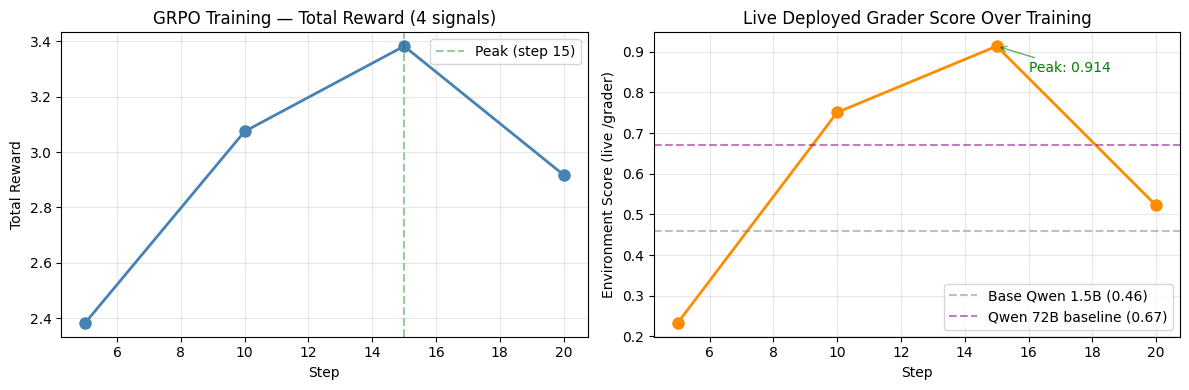

✓ Saved reward_curve.png


In [ ]:
import matplotlib.pyplot as plt

# Manually reconstruct the log from the values you already have
steps     = [5,     10,    15,    20]
rewards   = [2.383, 3.075, 3.383, 2.918]
env_score = [0.233, 0.751, 0.914, 0.522]
format_r  = [0.800, 0.950, 1.000, 0.950]
math_r    = [0.350, 0.374, 0.469, 0.446]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Total reward
ax1.plot(steps, rewards, linewidth=2, color="steelblue", marker="o", markersize=8)
ax1.set_xlabel("Step")
ax1.set_ylabel("Total Reward")
ax1.set_title("GRPO Training — Total Reward (4 signals)")
ax1.grid(True, alpha=0.3)
ax1.axvline(x=15, color="green", linestyle="--", alpha=0.4, label="Peak (step 15)")
ax1.legend()

# Environment score (live grader)
ax2.plot(steps, env_score, linewidth=2, color="darkorange", marker="o", markersize=8)
ax2.set_xlabel("Step")
ax2.set_ylabel("Environment Score (live /grader)")
ax2.set_title("Live Deployed Grader Score Over Training")
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.46, color="gray", linestyle="--", alpha=0.5, label="Base Qwen 1.5B (0.46)")
ax2.axhline(y=0.67, color="purple", linestyle="--", alpha=0.5, label="Qwen 72B baseline (0.67)")
ax2.annotate(f"Peak: 0.914",
             xy=(15, 0.914), xytext=(16, 0.85),
             fontsize=10, color="green",
             arrowprops=dict(arrowstyle="->", color="green", alpha=0.6))
ax2.legend(loc="lower right")

plt.tight_layout()
plt.savefig("reward_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved reward_curve.png")

In [ ]:
# Save the trained LoRA adapter
output_dir = "extractor_lora_grpo"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"✓ Saved LoRA adapter to {output_dir}")
print(f"  Files:")
import os
for f in os.listdir(output_dir):
    size_mb = os.path.getsize(os.path.join(output_dir, f)) / 1e6
    print(f"    {f}  ({size_mb:.1f} MB)")

Unsloth: Restored added_tokens_decoder metadata in extractor_lora_grpo/tokenizer_config.json.


✓ Saved LoRA adapter to extractor_lora_grpo
  Files:
    README.md  (0.0 MB)
    tokenizer.json  (11.4 MB)
    chat_template.jinja  (0.0 MB)
    tokenizer_config.json  (0.0 MB)
    adapter_model.safetensors  (73.9 MB)
    adapter_config.json  (0.0 MB)


In [ ]:
import os
# When was the file written?
files = os.listdir("extractor_lora_grpo")
adapter_path = "extractor_lora_grpo/adapter_model.safetensors"
mtime = os.path.getmtime(adapter_path)
import datetime
print(f"adapter_model.safetensors last modified: {datetime.datetime.fromtimestamp(mtime)}")

# And was checkpoint-10 saved before this?
ckpt10_path = "./grpo_invoice_output_v2/checkpoint-10/adapter_model.safetensors"
if os.path.exists(ckpt10_path):
    ckpt10_mtime = os.path.getmtime(ckpt10_path)
    print(f"checkpoint-10/adapter:        {datetime.datetime.fromtimestamp(ckpt10_mtime)}")

adapter_model.safetensors last modified: 2026-04-25 05:42:36.124407
checkpoint-10/adapter:        2026-04-25 05:31:06.986885


In [ ]:
import shutil
import os

# 1. Wipe the bad save
shutil.rmtree("extractor_lora_grpo")

# 2. Copy checkpoint-10 contents into extractor_lora_grpo
shutil.copytree("./grpo_invoice_output_v2/checkpoint-10", "extractor_lora_grpo")

# 3. Save tokenizer into the same folder (checkpoints often don't include tokenizer files)
tokenizer.save_pretrained("extractor_lora_grpo")

# 4. Verify
print("Final contents of extractor_lora_grpo:")
for f in sorted(os.listdir("extractor_lora_grpo")):
    size_mb = os.path.getsize(f"extractor_lora_grpo/{f}") / 1e6
    print(f"  {f}  ({size_mb:.2f} MB)")

Final contents of extractor_lora_grpo:
  README.md  (0.01 MB)
  adapter_config.json  (0.00 MB)
  adapter_model.safetensors  (73.91 MB)
  chat_template.jinja  (0.00 MB)
  optimizer.pt  (37.97 MB)
  rng_state.pth  (0.01 MB)
  scaler.pt  (0.00 MB)
  scheduler.pt  (0.00 MB)
  tokenizer.json  (11.42 MB)
  tokenizer_config.json  (0.00 MB)
  trainer_state.json  (0.00 MB)
  training_args.bin  (0.01 MB)


In [ ]:
import torch, gc
from unsloth import FastLanguageModel
from peft import PeftModel

# Clear current in-memory model (the collapsed one)
try:
    del model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

# Reload base
base, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)

# Load the swapped-in checkpoint-10
model = PeftModel.from_pretrained(base, "extractor_lora_grpo")
FastLanguageModel.for_inference(model)
print("✓ Loaded extractor_lora_grpo (= checkpoint-10, env_score 0.751)")

# Test on a real prompt
test_prompt = train_dataset[0]["prompt"]
inputs = tokenizer.apply_chat_template(
    test_prompt, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

with torch.no_grad():
    out = model.generate(
        inputs, max_new_tokens=512, temperature=0.3,
        do_sample=True, pad_token_id=tokenizer.eos_token_id
    )

print("\n--- INVOICE INPUT ---")
print(test_prompt[1]["content"][:400])
print("\n--- TRAINED MODEL OUTPUT ---")
print(tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True))

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ Loaded extractor_lora_grpo (= checkpoint-10, env_score 0.751)

--- INVOICE INPUT ---
INVOICE
-------
Invoice #: INV-18414
Vendor: Prime Office Supplies
Date: 2024-09-04
Currency: GBP

Items:
Description                      Qty   Unit Price       Amount
------------------------------ ----- ------------ ------------
Laptop Computer                   15 £   1162.02 £  17430.30
USB-C Hub                         20 £     76.42 £   1528.40
                                            TO

--- TRAINED MODEL OUTPUT ---
```json
{
  "vendor": "Prime Office Supplies",
  "date": "2024-09-04",
  "currency": "GBP",
  "total": 18958.70,
  "line_items": [
    {
      "description": "Laptop Computer",
      "qty": 15,
      "unit_price": 1162.02,
      "amount": 17430.30
    },
    {
      "description": "USB-C Hub",
      "qty": 20,
      "unit_price": 76.42,
      "amount": 1528.40
    }
  ]
}
```


In [ ]:
SYSTEM_PROMPT = TASK_PROMPTS["easy"]  # default prompt for inference eval

FastLanguageModel.for_inference(model)

test_invoice = """INVOICE
Vendor: Acme Corp
Date: 2024-08-15
Currency: USD

Items:
  Laptop Computer: qty=2 unit_price=$1099.99 amount=$2199.98
  Wireless Mouse: qty=5 unit_price=$34.99 amount=$174.95

TOTAL: $2374.93"""

messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user",   "content": test_invoice},
]
inputs = tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

with torch.no_grad():
    outputs = model.generate(inputs, max_new_tokens=512, temperature=0.1, do_sample=True)

response = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
print("Model output:\n", response)
print("\nParsed:")
print(json.dumps(_parse_json_safe(response), indent=2))


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Model output:
 ```json
{
  "vendor": "Acme Corp",
  "date": "2024-08-15",
  "currency": "USD",
  "total": 2374.93,
  "line_items": [
    {
      "description": "Laptop Computer",
      "qty": 2,
      "unit_price": 1099.99,
      "amount": 2199.98
    },
    {
      "description": "Wireless Mouse",
      "qty": 5,
      "unit_price": 34.99,
      "amount": 174.95
    }
  ]
}
```

Parsed:
{
  "vendor": "Acme Corp",
  "date": "2024-08-15",
  "currency": "USD",
  "total": 2374.93,
  "line_items": [
    {
      "description": "Laptop Computer",
      "qty": 2,
      "unit_price": 1099.99,
      "amount": 2199.98
    },
    {
      "description": "Wireless Mouse",
      "qty": 5,
      "unit_price": 34.99,
      "amount": 174.95
    }
  ]
}


In [ ]:
from huggingface_hub import login, whoami, HfApi

# 1. Paste your fresh WRITE token here (starts with hf_)
TOKEN = "HF_token"

# 2. Login + verify
login(token=TOKEN, add_to_git_credential=False)
me = whoami(token=TOKEN)
USERNAME = me["name"]
print(f"✓ Logged in as: {USERNAME}")

# 3. Build repo ID with YOUR actual username
REPO_ID = f"{USERNAME}/extractor-lora-qwen2.5-1.5b"
print(f"Pushing to: {REPO_ID}")

# 4. Create + upload (explicit token on every call)
api = HfApi()
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True, token=TOKEN)
api.upload_folder(
    folder_path="extractor_lora_grpo",
    repo_id=REPO_ID,
    repo_type="model",
    commit_message="extractor lora",
    token=TOKEN,
)
print(f"\n✓ https://huggingface.co/{REPO_ID}")

✓ Logged in as: ps2181
Pushing to: ps2181/extractor-lora-qwen2.5-1.5b


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...r_lora_grpo/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

...

  ...adapter_model.safetensors:   0%|          | 45.7kB / 75.0MB            

  ...or_lora_grpo/optimizer.pt:  15%|#5        | 5.84MB / 38.0MB            

  ...or_lora_grpo/scheduler.pt:  15%|#5        |   225B / 1.47kB            

  ...ra_grpo/training_args.bin:  15%|#5        | 1.03kB / 6.67kB            


✓ https://huggingface.co/ps2181/extractor-lora-qwen2.5-1.5b
